# Using G2ELin for beginners : 
Learn to use the main blocks of the tool (Building a network from scratch or calling a preset network --> Power Flow (PandaPower) --> Modal analysis toolbox --> EMT time-domain simulations)

## 0. Initialisation and basic imports :

In [248]:
# The basic imports :
%matplotlib inline
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)

# The imports related to the G2ELin library :
from g2elin_core.network.schema import (
    Bus, Line, Transformer, Load, DerUnit, Network, BusType, UnitType, GfmController,
)
from g2elin_core.network.validation import validate_network
from g2elin_core.network.topology import compute_topology_layout
from g2elin_core.powerflow import run_power_flow
from g2elin_core.pipeline import linearize_network
from g2elin_core.modal import analyze

#### Run-time toggles

Section 6 (nonlinear EMT simulation) is one of the slowest cells in this
notebook -- a full *nonlinear* coupled-Newton time integration, not just
linear algebra. Defaults to **off** so "Restart Kernel and Run All"
finishes quickly; flip the flag to `True` and re-run to actually exercise
that section.

In [249]:
RUN_EMT_SECTION = True  # Section 6: nonlinear EMT time-domain simulation


## 1. Creating the network : 
a) creating the skeleton : either
- Create a network from scratch
- Load a preset network (SMIB, CIGRE distribution network, WSCC transmission network)

b) editing default parameters of each element

c) validating the network 

### 1.1. Loading a preset network : 
Available network presets :
1. CIGRE distribution (islanded) networks : 

    a) `cigre_islanded_1sm_1gfm_1gfl()`

    b) `cigre_islanded_1sm_2gfm_1gfl()`

    c) `cigre_islanded_1sm_3gfm_1gfl()`

    d) `cigre_islanded_2sm_2gfm_2gfl()`

2. WSCC transmission networks : 

    a) `wscc9_3sm()`

    b) `wscc9_2sm_1gfl()`

    c) `wscc9_1sm_2gfl()`

    d) `wscc9_1sm_1gfm_1gfl()`

    e) `wscc9_1sm_2gfm()`

    f) `wscc9_2sm_1gfm()`

    g) `wscc9_1gfm_2gfl()`

    h) `wscc9_3gfm()`

3. SMIB configurations : 

    a) `sm_smib()`

    b) `gfm_smib()`

    c) `gfl_smib()`

Each preset is a plain Python function, with no arguments, that returns a ready-to-use `Network` object.

In [250]:
# printing all available network presets
# (each preset is a plain, no-argument function living in g2elin_core.network.presets)

preset_names = [
    "cigre_islanded_1sm_1gfm_1gfl",
    "cigre_islanded_1sm_2gfm_1gfl",
    "cigre_islanded_1sm_3gfm_1gfl",
    "cigre_islanded_2sm_2gfm_2gfl",
    "wscc9_3sm",
    "wscc9_2sm_1gfl",
    "wscc9_1sm_2gfl",
    "wscc9_1sm_1gfm_1gfl",
    "wscc9_1sm_2gfm",
    "wscc9_2sm_1gfm",
    "wscc9_1gfm_2gfl",
    "wscc9_3gfm",
    "sm_smib",
    "gfm_smib",
    "gfl_smib",
]

print("Available network presets:")
for preset in preset_names:
    print(f"  - {preset}()")

Available network presets:
  - cigre_islanded_1sm_1gfm_1gfl()
  - cigre_islanded_1sm_2gfm_1gfl()
  - cigre_islanded_1sm_3gfm_1gfl()
  - cigre_islanded_2sm_2gfm_2gfl()
  - wscc9_3sm()
  - wscc9_2sm_1gfl()
  - wscc9_1sm_2gfl()
  - wscc9_1sm_1gfm_1gfl()
  - wscc9_1sm_2gfm()
  - wscc9_2sm_1gfm()
  - wscc9_1gfm_2gfl()
  - wscc9_3gfm()
  - sm_smib()
  - gfm_smib()
  - gfl_smib()


In [251]:
# selecting a network preset to use
preset_name = "cigre_islanded_1sm_1gfm_1gfl"

# loading the network preset (import the matching function, then call it -- no arguments needed)
from g2elin_core.network.presets import cigre_islanded_1sm_1gfm_1gfl

network_preset = cigre_islanded_1sm_1gfm_1gfl()

print(f"Network preset '{preset_name}' loaded successfully.")

Network preset 'cigre_islanded_1sm_1gfm_1gfl' loaded successfully.


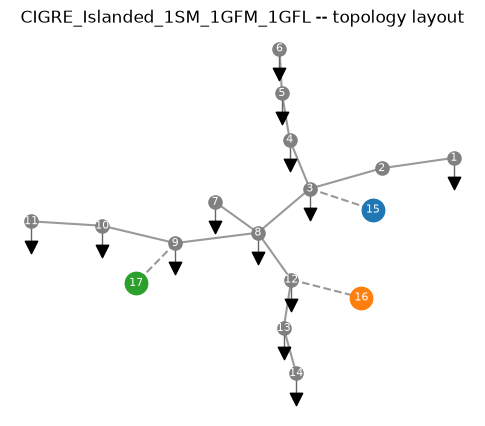

In [252]:
# Investigfating the network preset

# plotting the network topology
topology_layout = compute_topology_layout(network_preset)

fig, ax = plt.subplots(figsize=(6, 5))

# the (x, y) position of every bus, computed by compute_topology_layout
pos = {node.id: (node.x, node.y) for node in topology_layout.nodes}

# drawing every line/transformer as a segment between its two buses
for edge in topology_layout.edges:
    x1, y1 = pos[edge.from_bus]
    x2, y2 = pos[edge.to_bus]
    line_style = "--" if edge.kind == "transformer" else "-"  # dashed for transformers, solid for lines
    ax.plot([x1, x2], [y1, y2], line_style, color="0.6", zorder=1)

# drawing every bus as a dot, colored by the type of DER unit sitting on it (if any)
unit_colors = {"sm": "tab:blue", "gfm": "tab:orange", "gfl": "tab:green", "infinite_bus": "tab:red", None: "0.5"}
for node in topology_layout.nodes:
    ax.scatter(*pos[node.id], s=260 if node.unit_type else 90, color=unit_colors[node.unit_type], zorder=2)
    ax.annotate(str(node.id), pos[node.id], ha="center", va="center", fontsize=8, color="white", zorder=3)

# drawing a small flipped (downward-pointing) triangle for every bus that has a load,
# connected to its bus by a short stub line
load_offset = 0.15
for node in topology_layout.nodes:
    if node.load_p_mw is not None:
        x, y = pos[node.id]
        load_x, load_y = x, y - load_offset
        ax.plot([x, load_x], [y, load_y], "-", color="0.4", linewidth=1, zorder=1)
        ax.scatter(load_x, load_y, marker="v", s=80, color="black", zorder=2)

ax.set_title(f"{network_preset.name} -- topology layout")
ax.set_axis_off()
plt.show()

In [253]:
# Investigating elements parameters : 

# DER units parameters : 
print("DER units:")
display(pd.DataFrame([der.model_dump() for der in network_preset.der_units]))

# transformer parametrs : 
print("Transformers:")
display(pd.DataFrame([tr.model_dump() for tr in network_preset.transformers]))

# loads parameters :
print("Loads:")
display(pd.DataFrame([ld.model_dump() for ld in network_preset.loads]))

# lines parameters :
print("Lines:")
display(pd.DataFrame([ln.model_dump() for ln in network_preset.lines]))

DER units:


,id,bus,unit_type,bus_type,v_set_pu,p_set_mw,q_set_mvar,p_cons_mw,q_cons_mvar,controller,xd_pu
0,1,15,UnitType.SYNCHRONOUS_MACHINE,BusType.SLACK,1.0,1.25,0.0,0.0,0.0,None,0.2
1,2,16,UnitType.GFM,BusType.PV,1.0,2.50,0.0,0.0,0.0,GfmController.DROOP,NaN
2,3,17,UnitType.GFL,BusType.PQ,1.0,2.50,0.0,0.0,0.0,None,NaN


Transformers:


,hv_bus,lv_bus,r_pu,x_pu,sn_mva,name
0,3,15,0.0002,0.024,2.5,sm_xfmr
1,12,16,0.0002,0.024,2.5,gfm_xfmr
2,9,17,0.0002,0.024,2.5,gfl_xfmr


Loads:


,bus,p_mw,q_mvar,name
0,1,1.200,0.3500,
1,3,0.550,0.2664,
2,4,0.445,0.1115,
3,5,0.340,0.0852,
4,6,0.570,0.2761,
5,7,0.675,0.4183,
6,8,0.605,0.1516,
7,9,0.090,0.0558,
8,10,0.565,0.1416,
9,11,0.750,0.1880,


Lines:


,from_bus,to_bus,r_pu,x_pu,b_pu,length_km,name
0,2,1,0.0088,0.0126,0.0214,2.82,
1,2,3,0.0138,0.0198,0.0336,4.42,
2,4,3,0.0019,0.0027,0.0046,0.61,
3,4,5,0.0018,0.0025,0.0043,0.56,
4,6,5,0.0048,0.0069,0.0117,1.54,
5,8,3,0.0041,0.0058,0.0099,1.30,
6,8,7,0.0052,0.0075,0.0127,1.67,
7,8,9,0.0008,0.0011,0.0018,0.24,
8,10,9,0.0024,0.0034,0.0059,0.77,
9,10,11,0.0010,0.0014,0.0024,0.32,


### 1.2. Building a network from scratch

#### The convention a network builder has to respect

Paraphrasing `network.md`'s Validation section, and matching
`Functions/network_form.m`'s original MATLAB convention:

- Every DER unit (`sm`/`gfm`/`gfl`/`infinite_bus`) sits on **its own
  private bus**, reached from the rest of the network through **exactly
  one transformer** — never a `Line`, never shared with another DER, never
  another transformer's `hv_bus`.
- A DER's own local consumption is its `p_cons_mw`/`q_cons_mvar` fields,
  not a separate `Load` on its private bus.
- **Exactly one** DER unit has `bus_type = slack`, and for modal
  analysis/EMT to work it should be an `sm` or `infinite_bus` (a
  `gfm`/`gfl` slack is accepted for power flow but not wired into
  `interconnect.network_assembly` yet — `validate_network()` flags this
  as a warning, not an error).
- The whole graph (buses + lines + transformers) must be **connected** —
  every bus must be reachable from the slack.

None of that is specific to any one topology *shape* — a schema-valid
network can be meshed or radial, tiny or large, one DER or twenty.

In [254]:
# describing the raw_network (buses, lines and loads only) :

# two plain grid buses, at 20 kV
raw_buses = [
    Bus(id=1, name="bus1", vn_kv=20.0),
    Bus(id=2, name="bus2", vn_kv=20.0),
]

# one line joining the two grid buses
raw_lines = [
    Line(from_bus=1, to_bus=2, r_pu=0.01, x_pu=0.08, b_pu=0.02, length_km=5.0, name="line_1_2"),
]

# one load, at bus 2
raw_loads = [
    Load(bus=2, p_mw=1.0, q_mvar=0.3, name="load_bus2"),
]

print(f"{len(raw_buses)} buses, {len(raw_lines)} lines, {len(raw_loads)} loads")

2 buses, 1 lines, 1 loads


In [255]:
# Describing the DER units (IB, GFL, GFM and SM) and their transformers :
# Which DER is connected to which bus, and what are the parameters of the DER units and their transformers.

# Each DER unit sits on its own private bus, reached through exactly one transformer.
der_buses = [
    Bus(id=3, name="sm_terminal", vn_kv=10.0),   # the SM's own bus
    Bus(id=4, name="gfl_terminal", vn_kv=10.0),  # the GFL's own bus
]

der_units = [
    # The slack unit -- exactly one DER in the whole network must have bus_type = BusType.SLACK
    DerUnit(
        id=1, bus=3, unit_type=UnitType.SYNCHRONOUS_MACHINE, bus_type=BusType.SLACK,
        v_set_pu=1.0, p_set_mw=0.0, q_set_mvar=0.0, xd_pu=0.2,
    ),
    # A grid-following converter, dispatched at a fixed P and Q (a PQ bus)
    DerUnit(
        id=2, bus=4, unit_type=UnitType.GFL, bus_type=BusType.PQ,
        v_set_pu=1.0, p_set_mw=0.5, q_set_mvar=0.0,
    ),
]

# One transformer per DER unit : hv_bus = a plain grid bus, lv_bus = that DER's own bus
der_transformers = [
    Transformer(hv_bus=1, lv_bus=3, r_pu=0.0, x_pu=0.05, sn_mva=10.0, name="sm_xfmr"),
    Transformer(hv_bus=2, lv_bus=4, r_pu=0.0, x_pu=0.05, sn_mva=10.0, name="gfl_xfmr"),
]

print(f"{len(der_units)} DER units, {len(der_transformers)} transformers")

2 DER units, 2 transformers


In [256]:
# Complete network description (buses, lines, loads, DER units and transformers) :

network_from_scratch = Network(
    name="my_first_network",
    f_hz=50.0,
    sn_mva=10.0,
    buses=raw_buses + der_buses,
    lines=raw_lines,
    transformers=der_transformers,
    loads=raw_loads,
    der_units=der_units,
)

print(f"Network '{network_from_scratch.name}' created with "
      f"{len(network_from_scratch.buses)} buses and {len(network_from_scratch.der_units)} DER units.")

Network 'my_first_network' created with 4 buses and 2 DER units.


In [257]:
# Validating the network topology and parameters :
issues = validate_network(network_from_scratch)

if not issues:
    print("No issues found -- the network is ready for power flow / modal / EMT analysis.")
else:
    for issue in issues:
        print(f"[{issue.severity}] {issue.message}")

No issues found -- the network is ready for power flow / modal / EMT analysis.


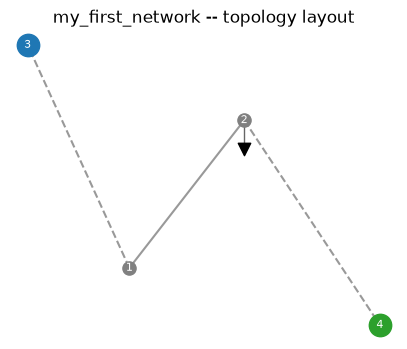

In [258]:
# Plotting the network topology :
topology_from_scratch = compute_topology_layout(network_from_scratch)

fig, ax = plt.subplots(figsize=(5, 4))
pos = {node.id: (node.x, node.y) for node in topology_from_scratch.nodes}

for edge in topology_from_scratch.edges:
    x1, y1 = pos[edge.from_bus]
    x2, y2 = pos[edge.to_bus]
    line_style = "--" if edge.kind == "transformer" else "-"
    ax.plot([x1, x2], [y1, y2], line_style, color="0.6", zorder=1)

unit_colors = {"sm": "tab:blue", "gfm": "tab:orange", "gfl": "tab:green", "infinite_bus": "tab:red", None: "0.5"}
for node in topology_from_scratch.nodes:
    ax.scatter(*pos[node.id], s=260 if node.unit_type else 90, color=unit_colors[node.unit_type], zorder=2)
    ax.annotate(str(node.id), pos[node.id], ha="center", va="center", fontsize=8, color="white", zorder=3)

# drawing a small flipped (downward-pointing) triangle for every bus that has a load,
# connected to its bus by a short stub line
load_offset = 0.15
for node in topology_from_scratch.nodes:
    if node.load_p_mw is not None:
        x, y = pos[node.id]
        load_x, load_y = x, y - load_offset
        ax.plot([x, load_x], [y, load_y], "-", color="0.4", linewidth=1, zorder=1)
        ax.scatter(load_x, load_y, marker="v", s=80, color="black", zorder=2)

ax.set_title(f"{network_from_scratch.name} -- topology layout")
ax.set_axis_off()
plt.show()

## 2. Power Flow (PandaPower) : 
pu-base --> power-flow 

In [259]:
# Computing the pu values of the network elements :
# (from here on, we continue with the preset network loaded in Section 1.1 : network_preset)
from g2elin_core.pu_base import pu_base

omega_base = 2 * math.pi * network_preset.f_hz  # base angular frequency (rad/s)

pu_base_values = pu_base(
    wb=omega_base,
    un_kv=network_preset.buses[0].vn_kv,
    sn_mva=network_preset.sn_mva,
)

print(f"Base angular frequency  : {omega_base:.4f} rad/s")
print(f"Base voltage (peak)     : {pu_base_values.ub:.4f} V")
print(f"Base current (peak)     : {pu_base_values.ib:.4f} A")
print(f"Base impedance          : {pu_base_values.zb:.4f} ohm")

Base angular frequency  : 314.1593 rad/s
Base voltage (peak)     : 16329.9316 V
Base current (peak)     : 102.0621 A
Base impedance          : 160.0000 ohm


In [260]:
# Selecting the power flow solver and parameters (PandaPower) :

# run_power_flow() forwards any keyword argument straight to pandapower's own runpp() solver.
powerflow_options = dict(
    algorithm="nr",       # "nr" = Newton-Raphson (default and most robust choice)
    max_iteration=10,     # maximum number of solver iterations
    tolerance_mva=1e-6,   # convergence tolerance, in MVA
)

print("Power flow solver options:", powerflow_options)

Power flow solver options: {'algorithm': 'nr', 'max_iteration': 10, 'tolerance_mva': 1e-06}


In [261]:
# Running the power flow :
power_flow_result = run_power_flow(network_preset, **powerflow_options)

print("Power flow converged:", power_flow_result.converged)

Power flow converged: True


In [262]:
# Power flow results (exposing all the reuslts of the power flow (PandaPower)) :

print(f"Total active power losses: {power_flow_result.total_losses_mw():.4f} MW")

print("\nBus results (voltage magnitude/angle, net power injected):")
display(power_flow_result.bus_table())

print("\nLine loading results:")
display(power_flow_result.line_table())

print("\nTransformer loading results:")
display(power_flow_result.trafo_table())

print("\nGenerator (PV DER) results:")
display(power_flow_result.gen_table())

print("\nStatic generator (PQ DER) results:")
display(power_flow_result.sgen_table())

print("\nSlack (external grid) results:")
display(power_flow_result.ext_grid_table())

Total active power losses: 0.0357 MW

Bus results (voltage magnitude/angle, net power injected):


,bus,vm_pu,va_degree,p_net_gen_mw,q_net_gen_mvar
0,1,0.9709,-2.0361,-1.2000,-0.3500
1,2,0.9769,-1.7395,-0.0000,-0.0000
2,3,0.9860,-1.2600,-0.5500,-0.2664
3,4,0.9844,-1.3281,-0.4450,-0.1115
4,5,0.9834,-1.3684,-0.3400,-0.0852
5,6,0.9816,-1.4317,-0.5700,-0.2761
6,7,0.9836,-1.1667,-0.6750,-0.4183
7,8,0.9862,-1.0973,-0.6050,-0.1516
8,9,0.9864,-1.0621,-0.0900,-0.0558
9,10,0.9847,-1.1510,-0.5650,-0.1416



Line loading results:


,name,from_bus,to_bus,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,,2,1,1.2058,0.3075,-1.2000,-0.3500,0.0058,-4.2535e-02,0.0368,0.0372,0.0372,0.9769,-1.7395,0.9709,-2.0361,0.0037
1,,2,3,-1.2058,-0.3075,1.2146,0.2392,0.0088,-6.8235e-02,0.0368,0.0362,0.0368,0.9769,-1.7395,0.9860,-1.2600,0.0037
2,,4,3,-1.3565,-0.4364,1.3581,0.4274,0.0016,-8.9644e-03,0.0418,0.0417,0.0418,0.9844,-1.3281,0.9860,-1.2600,0.0042
3,,4,5,0.9115,0.3248,-0.9108,-0.3342,0.0007,-9.3264e-03,0.0284,0.0285,0.0285,0.9844,-1.3281,0.9834,-1.3684,0.0029
4,,6,5,-0.5700,-0.2761,0.5708,0.2489,0.0008,-2.7115e-02,0.0186,0.0183,0.0186,0.9816,-1.4317,0.9834,-1.3684,0.0019
5,,8,3,0.8542,-0.4875,-0.8526,0.4657,0.0016,-2.1729e-02,0.0288,0.0284,0.0288,0.9862,-1.0973,0.9860,-1.2600,0.0029
6,,8,7,0.6763,0.3895,-0.6750,-0.4183,0.0013,-2.8865e-02,0.0228,0.0233,0.0233,0.9862,-1.0973,0.9836,-1.1667,0.0023
7,,8,9,-1.0920,0.4261,1.0924,-0.4299,0.0004,-3.8283e-03,0.0343,0.0344,0.0344,0.9862,-1.0973,0.9864,-1.0621,0.0034
8,,10,9,-1.3152,-0.3240,1.3171,0.3124,0.0018,-1.1605e-02,0.0397,0.0396,0.0397,0.9847,-1.1510,0.9864,-1.0621,0.0040
9,,10,11,0.7502,0.1824,-0.7500,-0.1880,0.0002,-5.5395e-03,0.0226,0.0227,0.0227,0.9847,-1.1510,0.9842,-1.1720,0.0023



Transformer loading results:


...

,name,bus,p_mw,q_mvar,va_degree,vm_pu
0,der2,16,2.5,1.0691,0.3276,1.0



Static generator (PQ DER) results:


,name,bus,p_mw,q_mvar
0,der3,17,2.5,0.0



Slack (external grid) results:


,name,bus,p_mw,q_mvar
0,der1,15,2.2707,1.469


## 3. Time-series static power-flow simulaion : 
- Simulating a load profile 
- Simulating different dispatch levels for the DERs

In [263]:
# Simulating a load profile at the different load buses of the network :
# The load profiles at the different load buses :

hours = np.arange(24)  # one point per hour of the day, from 0h to 23h

# A simple daily load-scaling curve: low at night, peak in the evening.
load_scaling_factor = 0.6 + 0.4 * np.sin((hours - 6) / 24 * 2 * np.pi) ** 2

# Building one time-series load profile (in MW) per load bus of the network,
# by applying the same daily scaling curve to each load's base active power.
load_profiles_mw = {
    load.bus: load.p_mw * load_scaling_factor
    for load in network_preset.loads
}

for bus_id, profile in load_profiles_mw.items():
    print(f"Load bus {bus_id}: from {profile.min():.3f} MW to {profile.max():.3f} MW")

Load bus 1: from 0.720 MW to 1.200 MW
Load bus 3: from 0.330 MW to 0.550 MW
Load bus 4: from 0.267 MW to 0.445 MW
Load bus 5: from 0.204 MW to 0.340 MW
Load bus 6: from 0.342 MW to 0.570 MW
Load bus 7: from 0.405 MW to 0.675 MW
Load bus 8: from 0.363 MW to 0.605 MW
Load bus 9: from 0.054 MW to 0.090 MW
Load bus 10: from 0.339 MW to 0.565 MW
Load bus 11: from 0.450 MW to 0.750 MW
Load bus 12: from 0.363 MW to 0.605 MW
Load bus 13: from 0.024 MW to 0.040 MW
Load bus 14: from 0.480 MW to 0.800 MW


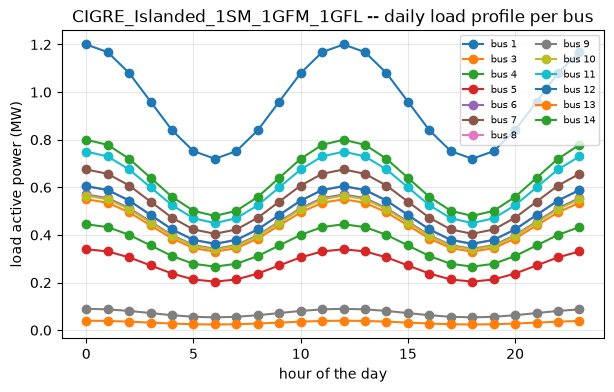

In [264]:
# Plotting the load profiles at the different load buses :
plt.figure(figsize=(7, 4))
for bus_id, profile in load_profiles_mw.items():
    plt.plot(hours, profile, marker="o", label=f"bus {bus_id}")
plt.xlabel("hour of the day")
plt.ylabel("load active power (MW)")
plt.title(f"{network_preset.name} -- daily load profile per bus")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

In [265]:
# Run batch power flow (PandaPower) : 
from g2elin_core.timeseries.scenario import Snapshot, run_time_series

# Simulating different dispatch levels for the DERs : a solar-like midday generation
# profile for the grid-forming (GFM) unit, peaking at noon.
gfm_der = next(der for der in network_preset.der_units if der.unit_type == UnitType.GFM)
gfm_p_max_mw = gfm_der.p_set_mw  # use the preset's own dispatch as the daily peak
gfm_dispatch_profile_mw = gfm_p_max_mw * np.clip(np.sin((hours - 6) / 12 * np.pi), 0.0, 1.0)

# One Snapshot per hour, overriding every load's P/Q (constant power factor)
# and the GFM unit's dispatched active power.
snapshots = [
    Snapshot(
        label=f"{hour:02d}h",
        der_p_mw={gfm_der.id: gfm_dispatch_profile_mw[hour]},
        load_p_mw={idx: load.p_mw * load_scaling_factor[hour] for idx, load in enumerate(network_preset.loads)},
        load_q_mvar={idx: load.q_mvar * load_scaling_factor[hour] for idx, load in enumerate(network_preset.loads)},
    )
    for hour in hours
]

time_series_result = run_time_series(network_preset, snapshots)

print("All 24 power flows converged:", time_series_result.all_converged())

All 24 power flows converged: True


,snapshot,bus,vm_pu,va_degree,p_net_gen_mw,q_net_gen_mvar
0,00h,1,0.9748,-3.4214,-1.200,-0.3500
1,00h,2,0.9809,-3.1272,-0.000,-0.0000
2,00h,3,0.9899,-2.6513,-0.550,-0.2664
3,00h,4,0.9884,-2.7188,-0.445,-0.1115
4,00h,5,0.9874,-2.7589,-0.340,-0.0852


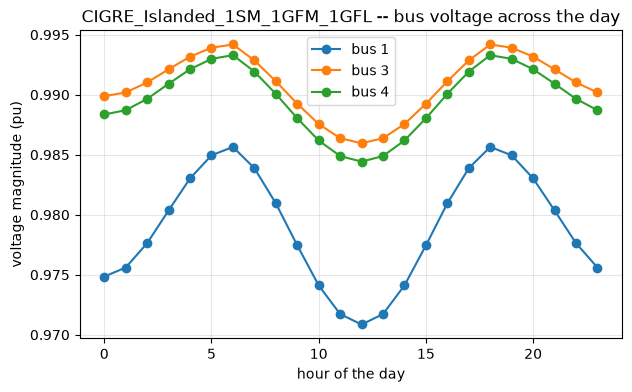

In [266]:
# Power flow results :
combined_results = time_series_result.combined_bus_table()
display(combined_results.head())

# Plotting the voltage at a few buses across the day :
watched_buses = [load.bus for load in network_preset.loads[:3]]

plt.figure(figsize=(7, 4))
for bus_id in watched_buses:
    bus_voltages = combined_results[combined_results["bus"] == bus_id]["vm_pu"].to_numpy()
    plt.plot(hours, bus_voltages, marker="o", label=f"bus {bus_id}")
plt.xlabel("hour of the day")
plt.ylabel("voltage magnitude (pu)")
plt.title(f"{network_preset.name} -- bus voltage across the day")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. State-space models and linearization :
- power-flow reuslts --> operating points 
- lineaization
- creating symbolic individual state spaces --> creating the global state-space (symbolic) --> The resulting overall state space after substituting with the parameters and operating points

In [267]:
# Computation of the individual linearised state-space model of the network (symbolic, before substituting the numerical values of the network parameters) :
from g2elin_core.components.sm import sm_dae
from g2elin_core.components.gfm import gfm_dae
from g2elin_core.components.gfl import gfl_dae
from g2elin_core.components.ib import ib_dae
from g2elin_core.components.node import node_dae
from g2elin_core.components.line import line_dae
from g2elin_core.components.load import load_dae

# Each DER unit type has its own symbolic model (a "DAE"): differential equations,
# algebraic constraints and outputs, with its Jacobians already taken symbolically
# (see g2elin_core.components.base.ComponentDAE) but no number plugged in yet.
der_daes = {}
for der in network_preset.der_units:
    if der.unit_type == UnitType.SYNCHRONOUS_MACHINE:
        der_daes[der.id] = sm_dae(is_slack=(der.bus_type == BusType.SLACK))
    elif der.unit_type == UnitType.GFM:
        der_daes[der.id] = gfm_dae()
    elif der.unit_type == UnitType.GFL:
        der_daes[der.id] = gfl_dae()
    elif der.unit_type == UnitType.INFINITE_BUS:
        der_daes[der.id] = ib_dae()

for der in network_preset.der_units:
    dae = der_daes[der.id]
    print(f"DER {der.id} ({der.unit_type.value}) : {len(dae.state_names)} states, "
          f"symbolic state Jacobian Fx is {dae.Fx.shape[0]} x {dae.Fx.shape[1]}")

DER 1 (sm) : 19 states, symbolic state Jacobian Fx is 19 x 19
DER 2 (gfm) : 15 states, symbolic state Jacobian Fx is 15 x 15
DER 3 (gfl) : 14 states, symbolic state Jacobian Fx is 14 x 14


In [268]:
# Computing of the closed-loop state space complete model of the network (always in symbolic) :

# In this library, per-unit Jacobians stay symbolic up to the point above, but assembling them
# into one closed-loop system always happens *after* substituting numerical values -- inverting
# a large matrix symbolically would be far too slow (see g2elin_core.components.base's own
# module docstring). So the only thing we can look at here, before any substitution, is the
# network's wiring structure : which block (DER/node/line/load) connects to which, and how many
# ports each one has. The actual closed-loop A/B/C/D matrices are computed numerically further
# down, once the operating point is known.
from g2elin_core.interconnect import build_blocks_and_wiring

der_bus_ids = {der.bus for der in network_preset.der_units}
plain_bus_ids = [bus.id for bus in network_preset.buses if bus.id not in der_bus_ids]

node_daes = {bus_id: node_dae() for bus_id in plain_bus_ids}
line_daes = [line_dae() for _ in network_preset.lines]
load_daes = [load_dae() for _ in network_preset.loads]

blocks, wiring = build_blocks_and_wiring(
    network_preset,
    der_components=der_daes,
    node_components=node_daes,
    line_components=line_daes,
    load_components=load_daes,
)

print(f"{len(blocks)} blocks, {len(wiring)} wiring rules")
for block in blocks:
    print(f"  {block.name:8s} kind={block.kind:9s} "
          f"own inputs={block.comp.n_us}, grid inputs={block.comp.n_ug}, "
          f"own outputs={block.comp.n_out_s}, grid outputs={block.comp.n_out_g}")

43 blocks, 154 wiring rules
  SM_1     kind=sm_slack  own inputs=3, grid inputs=2, own outputs=6, grid outputs=4
  GFM_1    kind=gfm       own inputs=5, grid inputs=3, own outputs=4, grid outputs=2
  GFL_1    kind=gfl       own inputs=3, grid inputs=3, own outputs=4, grid outputs=2
  Nd_1     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_2     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_3     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_4     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_5     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_6     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_7     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_8     kind=node      own inputs=0, grid inputs=3, own outputs=0, grid outputs=2
  Nd_9     kind=node      own inputs=

In [269]:
# Computation of the operating point of the network (the power flow results at the nominal load and generation levels) :
from g2elin_core.operating_point import compute_operating_point

operating_point = compute_operating_point(network_preset, power_flow_result)

print(f"Global reference angle theta_g : {operating_point.theta_g_rad:.5f} rad")
print(f"{len(operating_point.sm_ops)} SM, {len(operating_point.gfm_ops)} GFM, "
      f"{len(operating_point.gfl_ops)} GFL, {len(operating_point.ib_ops)} IB operating point(s) computed")

Global reference angle theta_g : -0.90592 rad
1 SM, 1 GFM, 1 GFL, 0 IB operating point(s) computed


In [270]:
# Printing the operating point of the network :
for der_id, sm_op in operating_point.sm_ops.items():
    print(f"SM (DER {der_id})  : theta0={sm_op.theta0:.4f} rad, Et0={sm_op.Et0:.4f} pu, Pm0={sm_op.Pm0:.4f} pu")

for der_id, gfm_op in operating_point.gfm_ops.items():
    print(f"GFM (DER {der_id}) : theta0={gfm_op.theta0:.4f} rad, "
          f"ved0={gfm_op.ved0:.4f} pu, veq0={gfm_op.veq0:.4f} pu")

for der_id, gfl_op in operating_point.gfl_ops.items():
    print(f"GFL (DER {der_id}) : theta_pll0={gfl_op.theta_pll0:.4f} rad, "
          f"isd0={gfl_op.isd0:.4f} pu, isq0={gfl_op.isq0:.4f} pu")

SM (DER 1)  : theta0=-0.9059 rad, Et0=1.0000 pu, Pm0=0.9083 pu
GFM (DER 2) : theta0=0.0057 rad, ved0=1.0000 pu, veq0=0.0000 pu
GFL (DER 3) : theta_pll0=0.0061 rad, isd0=1.0139 pu, isq0=0.1085 pu


In [271]:
# Computing of the individual state space after substituting the numerical values of the network parameters and operating points : 
from g2elin_core.components.sm import linearize_sm
from g2elin_core.components.gfm import linearize_gfm
from g2elin_core.components.gfl import linearize_gfl
from g2elin_core.components.ib import linearize_ib
from g2elin_core.components.node import linearize_node
from g2elin_core.components.line import linearize_line
from g2elin_core.components.load import linearize_load

wb_val = 2 * math.pi * network_preset.f_hz

# One numeric linear state-space per DER unit, built from its own operating point :
der_components = {}
for der_id, sm_op in operating_point.sm_ops.items():
    der_components[der_id] = linearize_sm(sm_op)
for der_id, gfm_op in operating_point.gfm_ops.items():
    der_components[der_id] = linearize_gfm(gfm_op)
for der_id, gfl_op in operating_point.gfl_ops.items():
    der_components[der_id] = linearize_gfl(gfl_op)
for der_id, ib_kwargs in operating_point.ib_ops.items():
    der_components[der_id] = linearize_ib(**ib_kwargs)

# One numeric linear state-space per plain grid node, line and load :
b_pu_quirk = network_preset.lines[0].b_pu if network_preset.lines else 0.0
node_components = {
    bus_id: linearize_node(wb_val=wb_val, b_pu=b_pu_quirk, wg0=1.0, vgd_g0=vgd, vgq_g0=vgq)
    for bus_id, (vgd, vgq) in operating_point.node_vg.items()
}
line_components = [
    linearize_line(wb_val=wb_val, r_pu=ln.r_pu, x_pu=ln.x_pu, wg0=1.0, ild_g0=i0[0], ilq_g0=i0[1])
    for ln, i0 in zip(network_preset.lines, operating_point.line_i0)
]
load_components = []
for idx, load in enumerate(network_preset.loads):
    r_pu, x_pu = operating_point.load_rx[idx]
    vgd, vgq = operating_point.node_vg[load.bus]
    load_components.append(linearize_load(wb_val=wb_val, r_pu=r_pu, x_pu=x_pu, wg0=1.0, vgd_g0=vgd, vgq_g0=vgq))

print(f"{len(der_components)} DER state spaces, {len(node_components)} node, "
      f"{len(line_components)} line, {len(load_components)} load state spaces computed")

3 DER state spaces, 14 node, 13 line, 13 load state spaces computed


In [272]:
# Computing of the complete closed-loop state space after substituting the numerical values of the network parameters and operating points : 
from g2elin_core.interconnect import assemble_network

closed_loop_system = assemble_network(
    network_preset,
    der_components=der_components,
    node_components=node_components,
    line_components=line_components,
    load_components=load_components,
)

print(f"Closed-loop state space : {len(closed_loop_system.state_names)} states, "
      f"{len(closed_loop_system.input_names)} inputs, {len(closed_loop_system.output_names)} outputs")

Closed-loop state space : 128 states, 11 inputs, 14 outputs


## 5. Modal Analysis toolbox : 
- Eigenvalue map & modal analysis summary 
- Participation factors (heatmap + single-mode participation)
- Sensitivity heatmap
- Mode shape
- Free motion response
- Forced step response

### 5.1. Eigenvalue map & modal analysis summary :

In [273]:
# Computing the modal analysis of the network (eigenvalues, damping ratios, participation factors) :
from g2elin_core.modal import analyze

modal = analyze(closed_loop_system.A, closed_loop_system.state_names)

# A tiny positive real part (e.g. 1e-10) is just floating-point noise around a
# structurally-zero eigenvalue (the reference-frame angle drift, not a real
# instability) -- so a mode only counts as unstable once its real part clears
# this tolerance. Matches g2elin_api.analysis's own stability check.
STABILITY_TOL = 1e-6

print(f"{len(modal.eigenvalues)} eigenvalues computed")
print("Network is stable:", bool(np.all(modal.eigenvalues.real < STABILITY_TOL)),
      " -- max Re(lambda):", modal.eigenvalues.real.max())

128 eigenvalues computed
Network is stable: True  -- max Re(lambda): 1.7377830538769947e-10


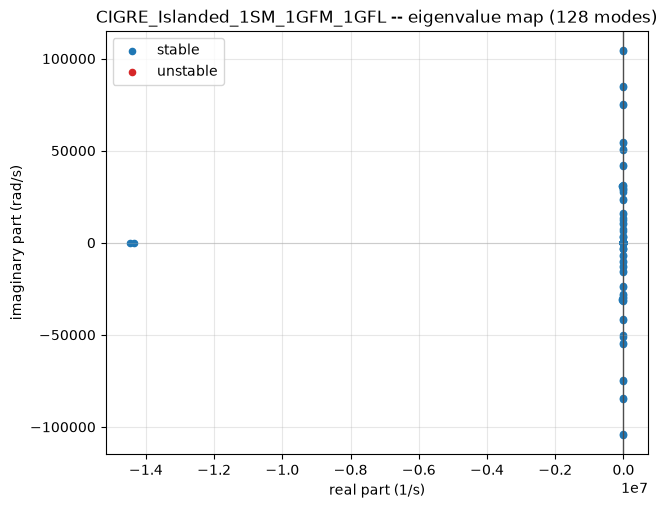

,mode,real,imag,undamped_hz,damped_hz,damping_pct,state1,part1_pct,state2,part2_pct,state3,part3_pct
127,127,1.7378e-10,0.0000,2.7658e-11,0.0000,-100.0000,theta_{GFM_1},53.1206,theta_{SM_1},46.8788,theta_pll_{GFL_1},0.0006
88,88,-1.1569e+02,104546.2185,1.6639e+04,16639.0475,0.1107,i_{l_d}_{Ln_8},18.6878,i_{l_q}_{Ln_8},18.6858,v_{g_d}_{Nd_8},12.9077
87,87,-1.1569e+02,-104546.2185,1.6639e+04,16639.0475,0.1107,i_{l_d}_{Ln_8},18.6878,i_{l_q}_{Ln_8},18.6858,v_{g_d}_{Nd_8},12.9077
85,85,-1.1569e+02,-103917.9000,1.6539e+04,16539.0475,0.1113,i_{l_q}_{Ln_8},18.6879,i_{l_d}_{Ln_8},18.6858,v_{g_q}_{Nd_8},12.9077
86,86,-1.1569e+02,103917.9000,1.6539e+04,16539.0475,0.1113,i_{l_q}_{Ln_8},18.6879,i_{l_d}_{Ln_8},18.6858,v_{g_q}_{Nd_8},12.9077
95,95,-1.1152e+02,-85006.7727,1.3529e+04,13529.2481,0.1312,i_{l_d}_{Ln_10},20.8197,i_{l_q}_{Ln_10},20.8183,v_{g_d}_{Nd_10},14.1081
96,96,-1.1152e+02,85006.7727,1.3529e+04,13529.2481,0.1312,i_{l_d}_{Ln_10},20.8197,i_{l_q}_{Ln_10},20.8183,v_{g_d}_{Nd_10},14.1081
93,93,-1.1152e+02,84378.4542,1.3429e+04,13429.2481,0.1322,i_{l_q}_{Ln_10},20.8198,i_{l_d}_{Ln_10},20.8182,v_{g_q}_{Nd_10},14.1081
94,94,-1.1152e+02,-84378.4542,1.3429e+04,13429.2481,0.1322,i_{l_q}_{Ln_10},20.8198,i_{l_d}_{Ln_10},20.8182,v_{g_q}_{Nd_10},14.1081
100,100,-1.1129e+02,75326.7445,1.1989e+04,11988.6237,0.1477,v_{g_d}_{Nd_4},14.4775,v_{g_q}_{Nd_4},14.3996,i_{l_d}_{Ln_4},12.2111


In [274]:
# Plotting the eigenvalues map and summary table :
fig, ax = plt.subplots(figsize=(7, 5.5))
stable = modal.eigenvalues.real < STABILITY_TOL
ax.scatter(modal.eigenvalues.real[stable], modal.eigenvalues.imag[stable], color="tab:blue", s=20, label="stable")
ax.scatter(modal.eigenvalues.real[~stable], modal.eigenvalues.imag[~stable], color="tab:red", s=20, label="unstable")
ax.axvline(0, color="0.3", linewidth=1)
ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("real part (1/s)")
ax.set_ylabel("imaginary part (rad/s)")
ax.set_title(f"{network_preset.name} -- eigenvalue map ({len(modal.eigenvalues)} modes)")
ax.legend()
plt.show()

# The modal analysis summary table : one row per mode, with its frequency,
# damping ratio, and the top-3 states participating in it.
summary_table = modal.summary_table()
display(summary_table.sort_values("damping_pct").head(10))

### 5.2. Participation factors (heatmap + single-mode participation) :

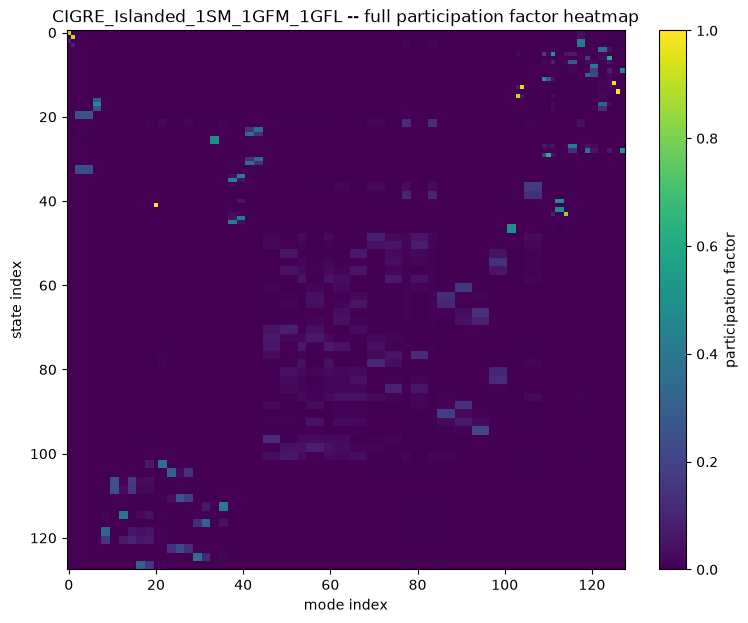

Participation factors (states 0-19, modes 0-14)


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M13,M14
i_gd_{SM_1},0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
i_gq_{SM_1},0.00,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
psi_d_{SM_1},0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
psi_q_{SM_1},0.00,0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
psi_fd_{SM_1},0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
psi_1d_{SM_1},0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
psi_1q_{SM_1},0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
psi_2q_{SM_1},0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
dw_r_{SM_1},0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
theta_{SM_1},0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [275]:
# Plotting of the complete participation factor heatmap of the network with the possibility to zoom in on a range of modes :

# The full heatmap (every state x every mode) :
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(modal.participation, aspect="auto", cmap="viridis")
ax.set_xlabel("mode index")
ax.set_ylabel("state index")
ax.set_title(f"{network_preset.name} -- full participation factor heatmap")
plt.colorbar(im, ax=ax, label="participation factor")
plt.show()

# "Zooming in" on a range of states/modes : shown as a shaded table, the same way
# the web UI'''s own participation heatmap does it -- light blue for small values,
# dark blue for large ones, and the value itself printed in each cell.
state_range_start, state_range_end = 0, 20
mode_range_start, mode_range_end = 0, 15

zoomed = pd.DataFrame(
    modal.participation[state_range_start:state_range_end, mode_range_start:mode_range_end],
    index=modal.state_names[state_range_start:state_range_end],
    columns=[f"M{m}" for m in range(mode_range_start, mode_range_end)],
)

light_blue, dark_blue = np.array([205, 226, 251]), np.array([13, 54, 107])
vmax = max(zoomed.to_numpy().max(), 1e-12)

def _shade_cell(value):
    t = min(1.0, max(0.0, abs(value) / vmax))
    r, g, b = (light_blue + (dark_blue - light_blue) * t).round().astype(int)
    text_color = "white" if t > 0.55 else "black"
    return f"background-color: rgb({r},{g},{b}); color: {text_color}"

print(f"Participation factors (states {state_range_start}-{state_range_end - 1}, "
      f"modes {mode_range_start}-{mode_range_end - 1})")
display(zoomed.style.map(_shade_cell).format("{:.2f}"))

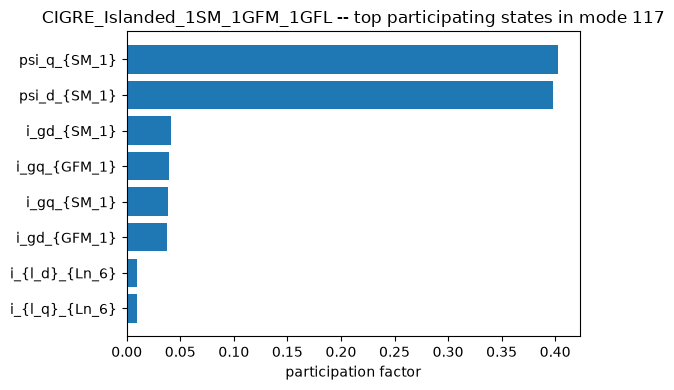

In [276]:
# Selection of a certain mode and plotting of a bar plot showing the states participating in that mode : 

# Picking an example mode to look at : the least-damped mode below 50 Hz, i.e. an
# oscillatory (nonzero imaginary part) power-system swing mode -- excluding the very
# fast (kHz-range) electrical modes, and the purely real reference-frame drift mode.
oscillatory_modes = summary_table[(summary_table["imag"] != 0) & (summary_table["undamped_hz"] < 50)]
mode_of_interest = int(oscillatory_modes.sort_values("damping_pct").iloc[0]["mode"])

participation_for_mode = modal.participation[:, mode_of_interest]
top_states_idx = np.argsort(participation_for_mode)[::-1][:8]

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(
    [modal.state_names[i] for i in top_states_idx][::-1],
    participation_for_mode[top_states_idx][::-1],
    color="tab:blue",
)
ax.set_xlabel("participation factor")
ax.set_title(f"{network_preset.name} -- top participating states in mode {mode_of_interest}")
plt.tight_layout()
plt.show()

### 5.3. Sensitivity heatmap :

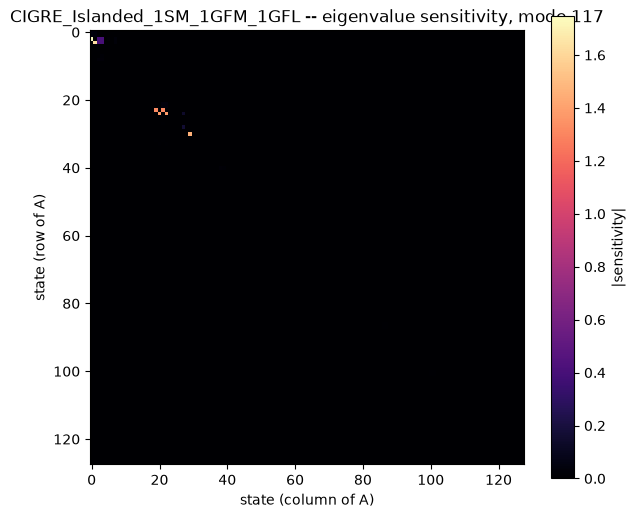

Top entries of the sensitivity matrix for mode 117 :
  d(lambda)/d(A[psi_d_{SM_1}, i_gd_{SM_1}]) ~= 1.745
  d(lambda)/d(A[psi_q_{SM_1}, i_gq_{SM_1}]) ~= 1.628
  d(lambda)/d(A[M_VLd_{GFM_1}, q_m_{GFM_1}]) ~= 1.463
  d(lambda)/d(A[v_eq_{GFM_1}, i_sq_{GFM_1}]) ~= 1.379
  d(lambda)/d(A[v_eq_{GFM_1}, i_gq_{GFM_1}]) ~= 1.379
  d(lambda)/d(A[v_ed_{GFM_1}, i_sd_{GFM_1}]) ~= 1.317
  d(lambda)/d(A[v_ed_{GFM_1}, i_gd_{GFM_1}]) ~= 1.317
  d(lambda)/d(A[psi_d_{SM_1}, psi_q_{SM_1}]) ~= 0.4079


In [277]:
# Selection of a certain mode to draw the full sensitivity matrix with a summary in text of the top entries :
from g2elin_core.modal import eigenvalue_sensitivity

sensitivity = eigenvalue_sensitivity(modal, closed_loop_system.A, mode_of_interest)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sensitivity.matrix, cmap="magma")
ax.set_xlabel("state (column of A)")
ax.set_ylabel("state (row of A)")
ax.set_title(f"{network_preset.name} -- eigenvalue sensitivity, mode {mode_of_interest}")
plt.colorbar(im, ax=ax, label="|sensitivity|")
plt.show()

print(f"Top entries of the sensitivity matrix for mode {mode_of_interest} :")
for entry in sensitivity.top:
    print(f"  d(lambda)/d(A[{entry.row_state}, {entry.col_state}]) ~= {entry.value:.4g}")

### 5.4. Mode shape :

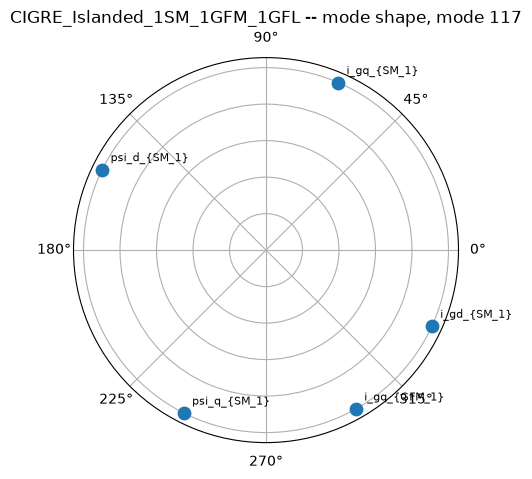

In [278]:
# Selection of a certain mode to draw the corresponding mode shape :
from g2elin_core.modal import mode_shape

shape = mode_shape(modal, mode_of_interest)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})
angles_rad = np.radians(shape.angles_deg)
ax.scatter(angles_rad, [1] * len(angles_rad), s=80, color="tab:blue", zorder=3)
for angle, state_name in zip(angles_rad, shape.states):
    ax.annotate(state_name, (angle, 1), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_yticklabels([])
ax.set_title(f"{network_preset.name} -- mode shape, mode {mode_of_interest}")
plt.show()

### 5.5. Free motion response :

In [279]:
# printing out all the available states, inputs and outputs for potential plotting : 
print(f"{len(closed_loop_system.state_names)} states :")
for name in closed_loop_system.state_names:
    print(f"  - {name}")

print(f"\n{len(closed_loop_system.input_names)} inputs :")
for name in closed_loop_system.input_names:
    print(f"  - {name}")

print(f"\n{len(closed_loop_system.output_names)} outputs :")
for name in closed_loop_system.output_names:
    print(f"  - {name}")

128 states :
  - i_gd_{SM_1}
  - i_gq_{SM_1}
  - psi_d_{SM_1}
  - psi_q_{SM_1}
  - psi_fd_{SM_1}
  - psi_1d_{SM_1}
  - psi_1q_{SM_1}
  - psi_2q_{SM_1}
  - dw_r_{SM_1}
  - theta_{SM_1}
  - P_m_{SM_1}
  - dw_1_{SM_1}
  - v_1_{SM_1}
  - v_2_{SM_1}
  - v_pss_{SM_1}
  - e_1_{SM_1}
  - e_2_{SM_1}
  - e_fd_{SM_1}
  - e_3_{SM_1}
  - i_sd_{GFM_1}
  - i_sq_{GFM_1}
  - i_gd_{GFM_1}
  - i_gq_{GFM_1}
  - v_ed_{GFM_1}
  - v_eq_{GFM_1}
  - v_dc_{GFM_1}
  - i_dc_{GFM_1}
  - p_m_{GFM_1}
  - theta_{GFM_1}
  - q_m_{GFM_1}
  - M_VLd_{GFM_1}
  - M_VLq_{GFM_1}
  - M_CLd_{GFM_1}
  - M_CLq_{GFM_1}
  - i_sd_{GFL_1}
  - i_sq_{GFL_1}
  - i_gd_{GFL_1}
  - i_gq_{GFL_1}
  - v_ed_{GFL_1}
  - v_eq_{GFL_1}
  - v_dc_{GFL_1}
  - i_dc_{GFL_1}
  - M_d_{GFL_1}
  - M_q_{GFL_1}
  - M_CLd_{GFL_1}
  - M_CLq_{GFL_1}
  - M_pll_{GFL_1}
  - theta_pll_{GFL_1}
  - v_{g_d}_{Nd_1}
  - v_{g_q}_{Nd_1}
  - v_{g_d}_{Nd_2}
  - v_{g_q}_{Nd_2}
  - v_{g_d}_{Nd_3}
  - v_{g_q}_{Nd_3}
  - v_{g_d}_{Nd_4}
  - v_{g_q}_{Nd_4}
  - v_{g_d}_{Nd_5}
  - 

In [280]:
# The selected state/or input for perturbation : 
mode_row = summary_table[summary_table["mode"] == mode_of_interest].iloc[0]
perturb_state_name = mode_row["state1"]  # the state that participates the most in our chosen mode
perturb_index = closed_loop_system.state_names.index(perturb_state_name)
initial_offset = 0.05  # pu, the size of the initial perturbation on that state

# The selected output(s) to monitor : 
monitored_output_names = closed_loop_system.output_names[:3]  # the first 3 exogenous outputs, as an example
monitored_output_indices = [closed_loop_system.output_names.index(name) for name in monitored_output_names]

print(f"Perturbing state '{perturb_state_name}' (index {perturb_index}) by {initial_offset} pu")
print(f"Monitoring outputs: {monitored_output_names}")

Perturbing state 'psi_q_{SM_1}' (index 3) by 0.05 pu
Monitoring outputs: ['p_e_{SM_1}', 'q_e_{SM_1}', 'w_r_{SM_1}']


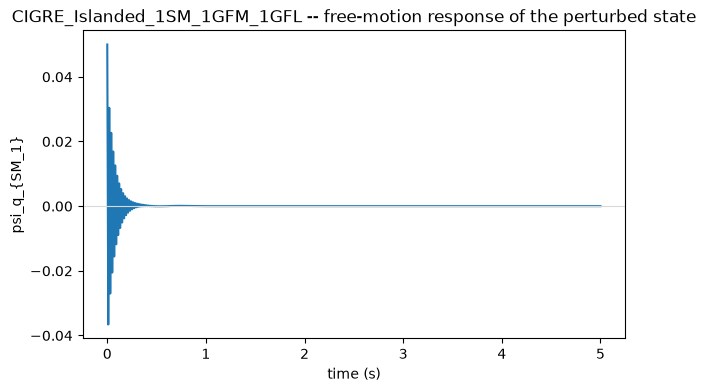

In [281]:
# plotting the perturbed state or input : 
from g2elin_core.modal import free_response

t_free = np.linspace(0, 5.0, 500)  # seconds
x_t = free_response(modal, perturb_index, initial_offset, t_free)

plt.figure(figsize=(7, 4))
plt.plot(t_free, x_t[perturb_index, :], color="tab:blue")
plt.axhline(0, color="0.85", linewidth=0.8)
plt.xlabel("time (s)")
plt.ylabel(perturb_state_name)
plt.title(f"{network_preset.name} -- free-motion response of the perturbed state")
plt.show()

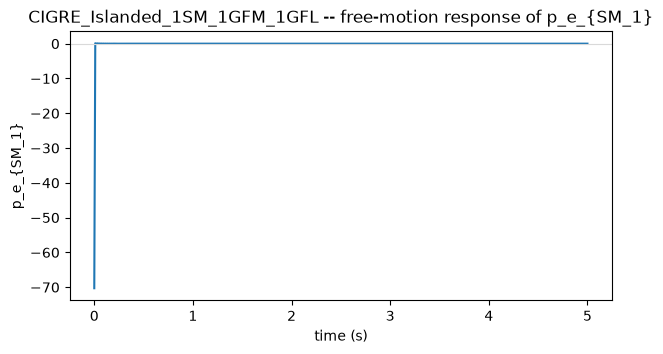

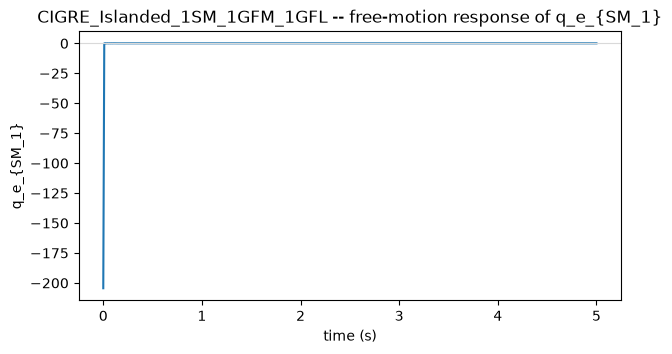

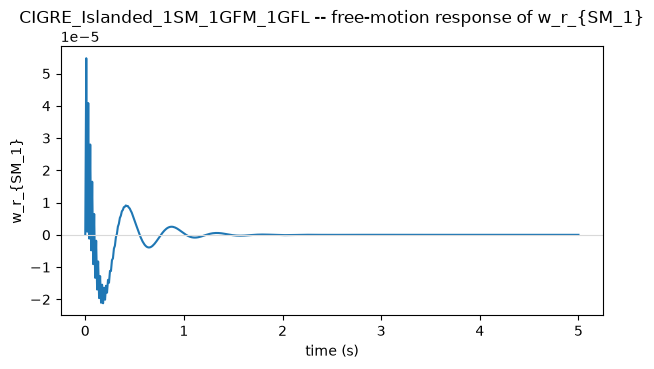

In [282]:
# Plotting the monitored output(s) : 
# No forcing input is applied here (free motion only), so the monitored outputs
# are simply y(t) = C @ x(t). One separate figure per monitored output.
y_t = closed_loop_system.C @ x_t

for idx, name in zip(monitored_output_indices, monitored_output_names):
    plt.figure(figsize=(7, 3.5))
    plt.plot(t_free, y_t[idx, :], color="tab:blue")
    plt.axhline(0, color="0.85", linewidth=0.8)
    plt.xlabel("time (s)")
    plt.ylabel(name)
    plt.title(f"{network_preset.name} -- free-motion response of {name}")
    plt.show()

### 5.6. Forced step response :

In [283]:
# The selected state/or input for perturbation and magnitude of perturbation :
step_input_name = closed_loop_system.input_names[0]  # the network's first exogenous input, as an example
step_amplitude = 0.05  # pu, the size of the step applied to that input

# The selected output(s) to monitor and magnitude of perturbation: 
step_output_names = closed_loop_system.output_names[:3]  # the first 3 exogenous outputs, as an example

print(f"Applying a {step_amplitude} pu step on input '{step_input_name}'")
print(f"Monitoring outputs: {step_output_names}")

Applying a 0.05 pu step on input 'V_ref_{SM_1}'
Monitoring outputs: ['p_e_{SM_1}', 'q_e_{SM_1}', 'w_r_{SM_1}']


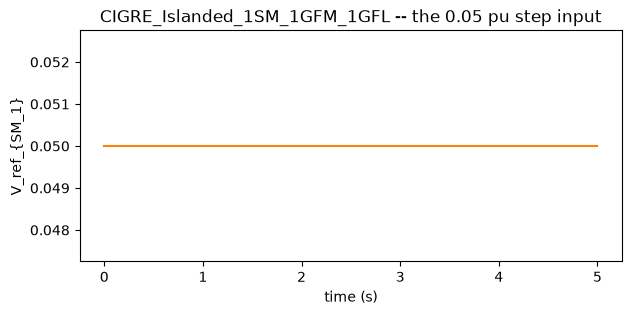

In [284]:
# plotting the perturbed state or input : 
t_step = np.linspace(0, 5.0, 500)  # seconds
step_input_signal = np.full_like(t_step, step_amplitude)  # a constant step, applied from t=0

plt.figure(figsize=(7, 3))
plt.plot(t_step, step_input_signal, color="tab:orange")
plt.xlabel("time (s)")
plt.ylabel(step_input_name)
plt.title(f"{network_preset.name} -- the {step_amplitude} pu step input")
plt.show()

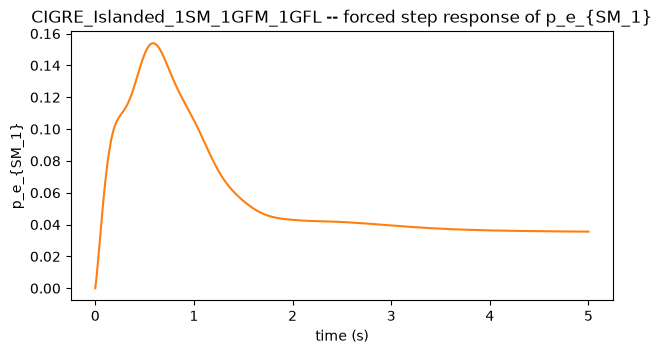

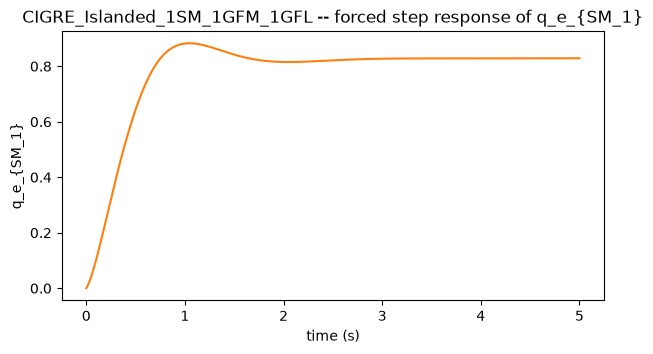

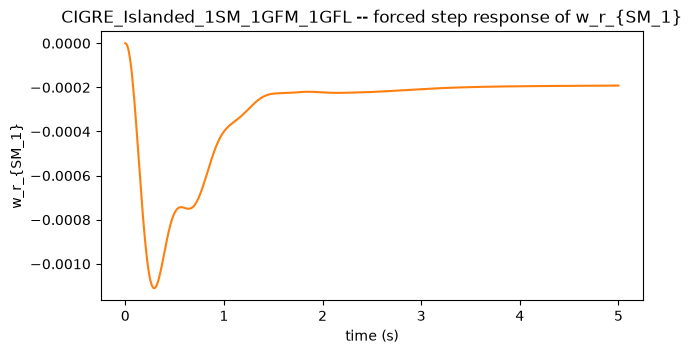

In [285]:
# Plotting the monitored output(s) : 
# One separate figure per monitored output.
from g2elin_core.modal import step_response

for output_name in step_output_names:
    y_step = step_response(closed_loop_system, step_input_name, output_name, step_amplitude, t_step)
    plt.figure(figsize=(7, 3.5))
    plt.plot(t_step, y_step, color="tab:orange")
    plt.xlabel("time (s)")
    plt.ylabel(output_name)
    plt.title(f"{network_preset.name} -- forced step response of {output_name}")
    plt.show()

## 6. EMT time-domain simulations : 
- Choice of the state or input to perturb 
- Choice of the solver and its parameters (timestep, .. )
- Choice of the variables to plot 
- Simulate + popup window of the live-plots
- plots in the notebook 
- comparison with linear model behaviour 

In [286]:
# Choice of the state/input to perturb and the magnitude of the perturbation :
from g2elin_core.timedomain import build_nonlinear_network

# The nonlinear model, built around the same operating point as the linear model in Section 4 :
nonlinear_model = build_nonlinear_network(network_preset, power_flow_result)

# Reusing the same input and step size chosen for the linear forced step response (Section 5.6),
# so the linear and nonlinear results can be compared directly further down :
emt_input_name = step_input_name
emt_step_amplitude = step_amplitude
emt_input_idx = nonlinear_model.input_names.index(emt_input_name)

# A permanent step on that input, applied for the whole simulation -- the model starts at its
# pre-step operating point, so this reproduces a classic step response.
perturbed_u_exo = nonlinear_model.default_u_exo().copy()
perturbed_u_exo[emt_input_idx] += emt_step_amplitude


def emt_u_exo(t):
    return perturbed_u_exo


print(f"Nonlinear model : {len(nonlinear_model.state_names)} states, "
      f"{len(nonlinear_model.input_names)} inputs, {len(nonlinear_model.output_names)} outputs")
print(f"Perturbing input '{emt_input_name}' with a {emt_step_amplitude} pu step")

Nonlinear model : 128 states, 11 inputs, 14 outputs
Perturbing input 'V_ref_{SM_1}' with a 0.05 pu step


In [287]:
# Choice of the solver and its parameters (timestep, .. ) :
emt_t_start, emt_t_end = 0.0, 1.5  # seconds -- kept short, this is a stiff nonlinear solve

emt_solver_options = dict(
    method="Radau",   # implicit, L-stable -- this system's fastest modes reach ~1e6-1e7 rad/s
    rtol=1e-5,
    atol=1e-7,
    first_step=1e-8,
)

print("EMT solver options:", emt_solver_options)
print(f"Simulating from t={emt_t_start}s to t={emt_t_end}s")

EMT solver options: {'method': 'Radau', 'rtol': 1e-05, 'atol': 1e-07, 'first_step': 1e-08}
Simulating from t=0.0s to t=1.5s


In [288]:
# Choice of the output(s) to monitor :
emt_output_names = nonlinear_model.output_names[:3]  # the first 3 named outputs, as an example
print(f"Monitoring outputs: {emt_output_names}")

Monitoring outputs: ['p_e_{SM_1}', 'q_e_{SM_1}', 'w_r_{SM_1}']


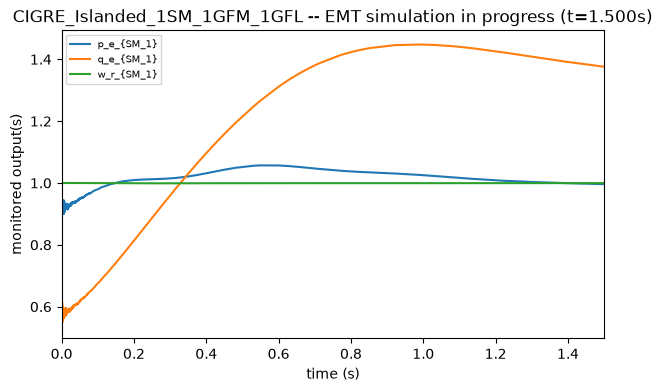

Simulation finished : 3148 accepted solver steps


In [289]:
# Start the simulation and plot the output(s) in live (pop-up window(s)) :
# A real separate OS pop-up window needs an interactive matplotlib backend (%matplotlib qt/tk),
# which isn't available in every environment this notebook runs in, and produces nothing at all
# when the notebook is executed non-interactively (e.g. "Restart Kernel and Run All", or
# nbconvert). So instead we get the same "watch it happen" effect directly in the notebook,
# redrawing a figure as the simulation progresses, using simulate_steps() (which yields one
# EmtStep -- state, inputs, outputs -- per accepted solver step) and IPython's live-display tools.
from IPython.display import display, clear_output
from g2elin_core.timedomain import simulate_steps

emt_t = []
emt_x = []
emt_inputs = {name: [] for name in nonlinear_model.input_names}
emt_outputs = {name: [] for name in nonlinear_model.output_names}

live_fig, live_ax = plt.subplots(figsize=(7, 4))

for i, step in enumerate(
    simulate_steps(nonlinear_model, (emt_t_start, emt_t_end), u_exo_fn=emt_u_exo, **emt_solver_options)
):
    emt_t.append(step.t)
    emt_x.append(step.x)
    for name, value in step.inputs.items():
        emt_inputs[name].append(value)
    for name, value in step.outputs.items():
        emt_outputs[name].append(value)

    if i % 25 == 0 or step.t >= emt_t_end:
        live_ax.clear()
        for name in emt_output_names:
            live_ax.plot(emt_t, emt_outputs[name], label=name)
        live_ax.set_xlim(emt_t_start, emt_t_end)
        live_ax.set_xlabel("time (s)")
        live_ax.set_ylabel("monitored output(s)")
        live_ax.set_title(f"{network_preset.name} -- EMT simulation in progress (t={step.t:.3f}s)")
        live_ax.legend(fontsize=7)
        clear_output(wait=True)
        display(live_fig)

plt.close(live_fig)
emt_t = np.array(emt_t)
emt_x = np.array(emt_x).T  # shape (n_states, len(t))
emt_inputs = {name: np.array(values) for name, values in emt_inputs.items()}
emt_outputs = {name: np.array(values) for name, values in emt_outputs.items()}

print(f"Simulation finished : {len(emt_t)} accepted solver steps")

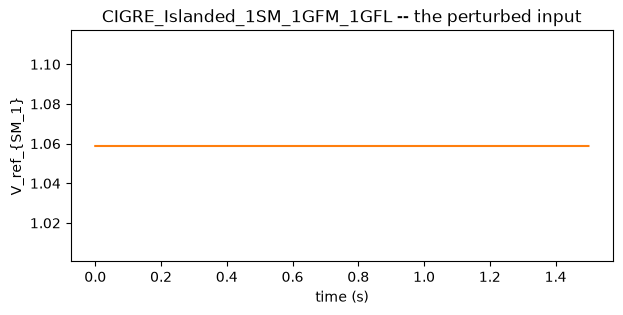

In [290]:
# Plotting of the final inputs / states perturbed :
plt.figure(figsize=(7, 3))
plt.plot(emt_t, emt_inputs[emt_input_name], color="tab:orange")
plt.xlabel("time (s)")
plt.ylabel(emt_input_name)
plt.title(f"{network_preset.name} -- the perturbed input")
plt.show()

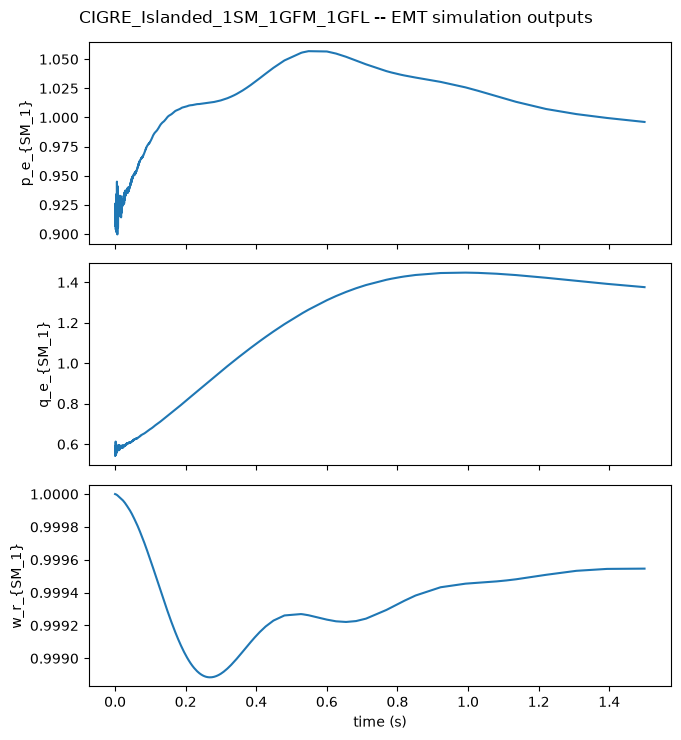

In [291]:
# Plotting of the final output(s) after the simulation is finished, in a single figure with subplots for each output :
fig, axes = plt.subplots(len(emt_output_names), 1, figsize=(7, 2.5 * len(emt_output_names)), sharex=True)
if len(emt_output_names) == 1:
    axes = [axes]
for ax, name in zip(axes, emt_output_names):
    ax.plot(emt_t, emt_outputs[name], color="tab:blue")
    ax.set_ylabel(name)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"{network_preset.name} -- EMT simulation outputs")
plt.tight_layout()
plt.show()

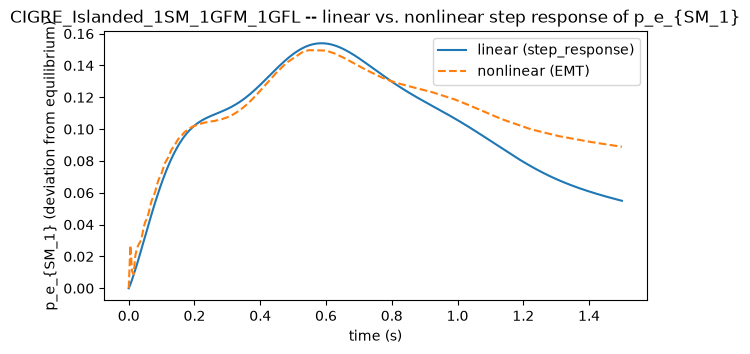

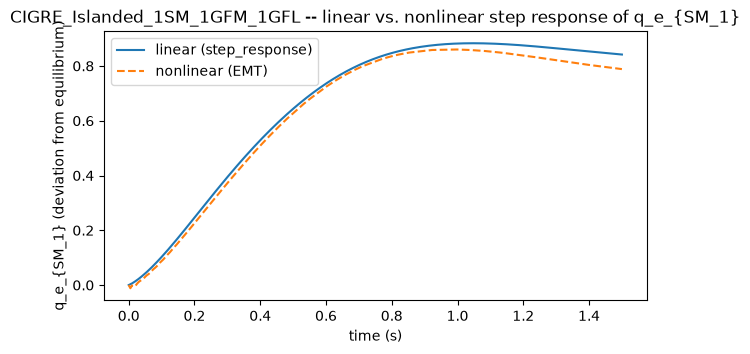

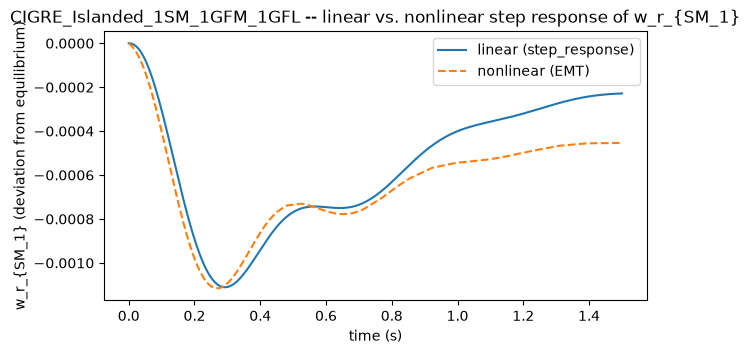

In [292]:
# Comparing the results of the simulation with the results of the linearised model (step response) :
from g2elin_core.modal import step_response

# The nonlinear model'''s own outputs at its pre-step operating point, used as the baseline
# so both curves show a *deviation* from the same equilibrium (the linear model'''s own convention).
_, baseline_outputs = nonlinear_model.recover_inputs_and_outputs(
    np.array([0.0]), nonlinear_model.initial_state().reshape(-1, 1)
)

# step_response() needs equally-spaced time samples, but the EMT solver'''s own accepted steps
# (emt_t) are not evenly spaced -- so we compare on a separate, uniform time grid instead,
# interpolating the nonlinear trace onto it.
emt_t_uniform = np.linspace(emt_t[0], emt_t[-1], 300)

for name in emt_output_names:
    y_lin = step_response(closed_loop_system, emt_input_name, name, emt_step_amplitude, emt_t_uniform)
    y_nonlin_raw = emt_outputs[name] - baseline_outputs[name][0]
    y_nonlin = np.interp(emt_t_uniform, emt_t, y_nonlin_raw)

    plt.figure(figsize=(7, 3.5))
    plt.plot(emt_t_uniform, y_lin, color="tab:blue", label="linear (step_response)")
    plt.plot(emt_t_uniform, y_nonlin, color="tab:orange", linestyle="--", label="nonlinear (EMT)")
    plt.xlabel("time (s)")
    plt.ylabel(f"{name} (deviation from equilibrium)")
    plt.title(f"{network_preset.name} -- linear vs. nonlinear step response of {name}")
    plt.legend()
    plt.show()

## 7. Additional analysis : 
- plotting the root locus of the mode map for changing a parameter.
- Simulating a step-response in an input with linear forced response versus EMT time-domain simulations
- Simulating the loss of a DER 
- Simulating the loss of a load

### 7.1. plotting the root locus of the mode map for changing a parameter :

In [293]:
# Options of the parameters to change :
# modifying the time-response of the inner current loop of the GFM units (all of them at once)
# or modifying the outer voltage loop time-response, or the GFM's droop gain,
# or same for GFL units or the GFL's PLL bandwidth.
# Modifying the SM's inertia or daming.

# Here : sweeping the GFM's inner current-loop rise time (tr_cl) -- a smaller value means a
# faster (more aggressive) current controller. See g2elin_core.operating_point.gfm_params.
from g2elin_core.operating_point import gfm_params

gfm_der = next(der for der in network_preset.der_units if der.unit_type == UnitType.GFM)
gfm_op = operating_point.gfm_ops[gfm_der.id]
gfm_un_kv = network_preset.bus(gfm_der.bus).vn_kv
first_tr = network_preset.transformers[0]

tr_cl_values = np.array([0.05e-3, 0.1e-3, 0.2e-3, 0.4e-3, 0.8e-3, 1.6e-3, 3.2e-3, 6.4e-3])

print(f"Sweeping the GFM (DER {gfm_der.id})'s inner current-loop rise time over "
      f"{len(tr_cl_values)} values (ms): {tr_cl_values * 1000}")

Sweeping the GFM (DER 2)'s inner current-loop rise time over 8 values (ms): [0.05 0.1  0.2  0.4  0.8  1.6  3.2  6.4 ]


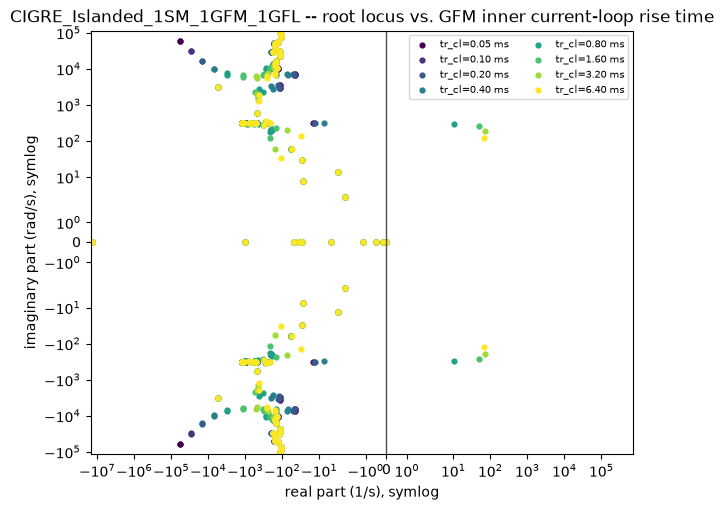

In [294]:
# Plotting the root-locus of the modes (modal map with the eigenvalues moving as a parameter is varied) :
sweep_results = []
for tr_cl in tr_cl_values:
    p = gfm_params(
        sn_mva=network_preset.sn_mva, f_hz=network_preset.f_hz, un_kv=gfm_un_kv,
        rt_pu=first_tr.r_pu, lt_pu=first_tr.x_pu, tr_cl=tr_cl,
    )
    gfm_op.p["KpCL"], gfm_op.p["KiCL"] = p["KpCL"], p["KiCL"]

    swept_der_components = {**der_components, gfm_der.id: linearize_gfm(gfm_op)}
    swept_system = assemble_network(
        network_preset,
        der_components=swept_der_components,
        node_components=node_components,
        line_components=line_components,
        load_components=load_components,
    )
    swept_modal = analyze(swept_system.A, swept_system.state_names)
    sweep_results.append({"tr_cl": tr_cl, "eigenvalues": swept_modal.eigenvalues})

# symlog axes : most eigenvalues sit in a tight cluster near zero while a few very fast
# electrical modes sit far out along the real axis -- a plain linear scale would hide the
# sweep'''s actual effect inside that cluster.
fig, ax = plt.subplots(figsize=(7, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(sweep_results)))
for result, color in zip(sweep_results, colors):
    ax.scatter(result["eigenvalues"].real, result["eigenvalues"].imag, s=12, color=color,
               label=f"tr_cl={result['tr_cl'] * 1000:.2f} ms")
ax.axvline(0, color="0.3", linewidth=1)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.set_xlabel("real part (1/s), symlog")
ax.set_ylabel("imaginary part (rad/s), symlog")
ax.set_title(f"{network_preset.name} -- root locus vs. GFM inner current-loop rise time")
ax.legend(fontsize=7, ncol=2)
plt.show()

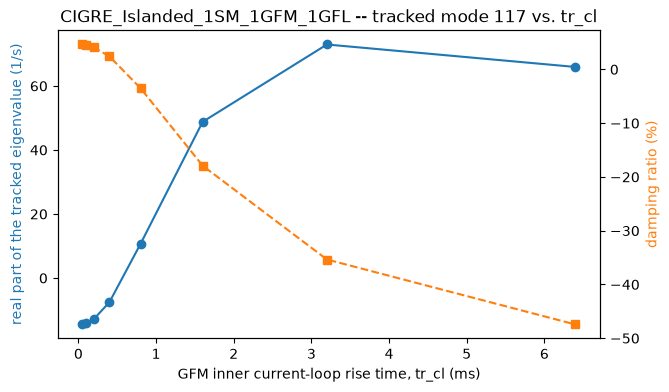

In [295]:
# Selecting a mode to show the real part of the eigenvalue as a function of the parameter varied, and the damping ratio as a function of the parameter varied.

# Tracking a single mode across the sweep by nearest-eigenvalue matching from one parameter
# value to the next (eig() doesn't guarantee a stable mode ordering as a parameter changes) --
# starting from the same mode of interest picked in Section 5.2.
tracked_eigenvalue = modal.eigenvalues[mode_of_interest]
tracked_real, tracked_damping_pct = [], []
for result in sweep_results:
    idx_closest = np.argmin(np.abs(result["eigenvalues"] - tracked_eigenvalue))
    tracked_eigenvalue = result["eigenvalues"][idx_closest]
    tracked_real.append(tracked_eigenvalue.real)
    damping = -tracked_eigenvalue.real / abs(tracked_eigenvalue) * 100 if abs(tracked_eigenvalue) else 0.0
    tracked_damping_pct.append(damping)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(tr_cl_values * 1000, tracked_real, "o-", color="tab:blue")
ax2.plot(tr_cl_values * 1000, tracked_damping_pct, "s--", color="tab:orange")
ax1.set_xlabel("GFM inner current-loop rise time, tr_cl (ms)")
ax1.set_ylabel("real part of the tracked eigenvalue (1/s)", color="tab:blue")
ax2.set_ylabel("damping ratio (%)", color="tab:orange")
ax1.set_title(f"{network_preset.name} -- tracked mode {mode_of_interest} vs. tr_cl")
plt.show()

### 7.2. Simulating a step-response in an input with linear forced response versus EMT time-domain simulations

### 7.3. Simulating the loss of a DER : 

In [296]:
# Selecting the DER to be disconnected :
der_to_trip = next(der for der in network_preset.der_units if der.bus_type != BusType.SLACK)
print(f"Disconnecting DER {der_to_trip.id} ({der_to_trip.unit_type.value}) at bus {der_to_trip.bus}")

Disconnecting DER 2 (gfm) at bus 16


Power flow after DER loss converged: True


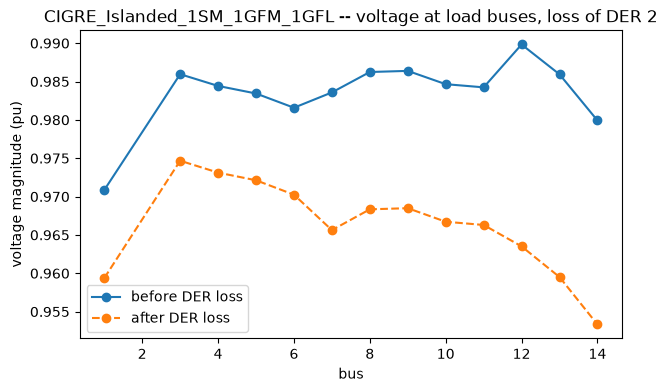

In [297]:
# Simulating the voltage drop at the load buses after the DER is disconnected, and plotting the voltage at the load buses before and after the DER disconnection :

# Removing the DER unit, its own transformer, and its own private bus -- leaving the bus behind
# would turn it into an orphaned, disconnected 1-bus island, which validate_network() flags.
network_after_der_loss = network_preset.model_copy(deep=True)
network_after_der_loss.der_units = [d for d in network_after_der_loss.der_units if d.id != der_to_trip.id]
network_after_der_loss.transformers = [
    tr for tr in network_after_der_loss.transformers if tr.lv_bus != der_to_trip.bus
]
network_after_der_loss.buses = [b for b in network_after_der_loss.buses if b.id != der_to_trip.bus]

der_loss_issues = validate_network(network_after_der_loss)
der_loss_errors = [issue for issue in der_loss_issues if issue.severity == "error"]
if der_loss_errors:
    for issue in der_loss_errors:
        print(f"[error] {issue.message}")
else:
    power_flow_after_der_loss = run_power_flow(network_after_der_loss)
    print("Power flow after DER loss converged:", power_flow_after_der_loss.converged)

    bus_table_before = power_flow_result.bus_table().set_index("bus")
    bus_table_after = power_flow_after_der_loss.bus_table().set_index("bus")
    load_buses = sorted({load.bus for load in network_preset.loads})

    plt.figure(figsize=(7, 4))
    plt.plot(load_buses, bus_table_before.loc[load_buses, "vm_pu"], "o-", label="before DER loss")
    plt.plot(load_buses, bus_table_after.loc[load_buses, "vm_pu"], "o--", label="after DER loss")
    plt.xlabel("bus")
    plt.ylabel("voltage magnitude (pu)")
    plt.title(f"{network_preset.name} -- voltage at load buses, loss of DER {der_to_trip.id}")
    plt.legend()
    plt.show()

### 7.4. Simulating the loss of a load : 

In [298]:
# Selecting the load to be disconnected :
load_idx_to_trip = 0
load_to_trip = network_preset.loads[load_idx_to_trip]
print(f"Disconnecting the load at bus {load_to_trip.bus} "
      f"(P={load_to_trip.p_mw} MW, Q={load_to_trip.q_mvar} MVAr)")

Disconnecting the load at bus 1 (P=1.2 MW, Q=0.35 MVAr)


Power flow after load loss converged: True


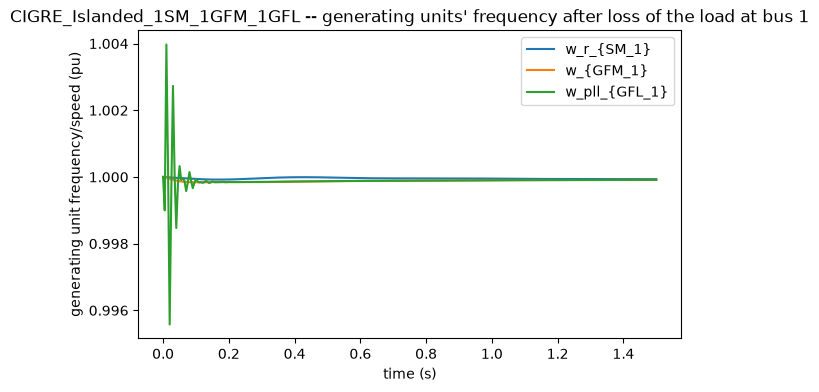

In [299]:
# Simulating the frequency response at the load buses after the load is disconnected, and plotting the frequency at the load buses before and after the DER disconnection :

# Note : this model has no per-bus frequency state -- a plain grid bus only has a dq-frame
# voltage, expressed in one common rotating reference frame (its speed, "wg", is an input, not
# a dynamic state). The only genuine frequency-like *outputs* this model produces belong to the
# generating units themselves : an SM's w_r, a GFM's w, or a GFL's w_pll. So instead of
# "frequency at a load bus" (not a quantity this model has), we look at the DER units' own
# frequency deviation after the load is disconnected.
from g2elin_core.timedomain import build_nonlinear_network, simulate

network_after_load_loss = network_preset.model_copy(deep=True)
network_after_load_loss.loads = [
    ld for i, ld in enumerate(network_after_load_loss.loads) if i != load_idx_to_trip
]

load_loss_issues = validate_network(network_after_load_loss)
load_loss_errors = [issue for issue in load_loss_issues if issue.severity == "error"]
if load_loss_errors:
    for issue in load_loss_errors:
        print(f"[error] {issue.message}")
else:
    power_flow_after_load_loss = run_power_flow(network_after_load_loss)
    print("Power flow after load loss converged:", power_flow_after_load_loss.converged)

    model_after_load_loss = build_nonlinear_network(network_after_load_loss, power_flow_after_load_loss)
    t_eval_load_loss = np.linspace(0, 1.5, 300)
    result_after_load_loss = simulate(
        model_after_load_loss, (0.0, 1.5), t_eval=t_eval_load_loss,
        method="Radau", rtol=1e-5, atol=1e-7, first_step=1e-8,
    )
    _, outputs_after_load_loss = model_after_load_loss.recover_inputs_and_outputs(
        result_after_load_loss.t, result_after_load_loss.x
    )

    frequency_output_names = [
        name for name in model_after_load_loss.output_names if name.split("_{")[0] in ("w", "w_r", "w_pll")
    ]

    plt.figure(figsize=(7, 4))
    for name in frequency_output_names:
        plt.plot(result_after_load_loss.t, outputs_after_load_loss[name], label=name)
    plt.xlabel("time (s)")
    plt.ylabel("generating unit frequency/speed (pu)")
    plt.title(f"{network_preset.name} -- generating units' frequency after loss of the load at bus {load_to_trip.bus}")
    plt.legend()
    plt.show()